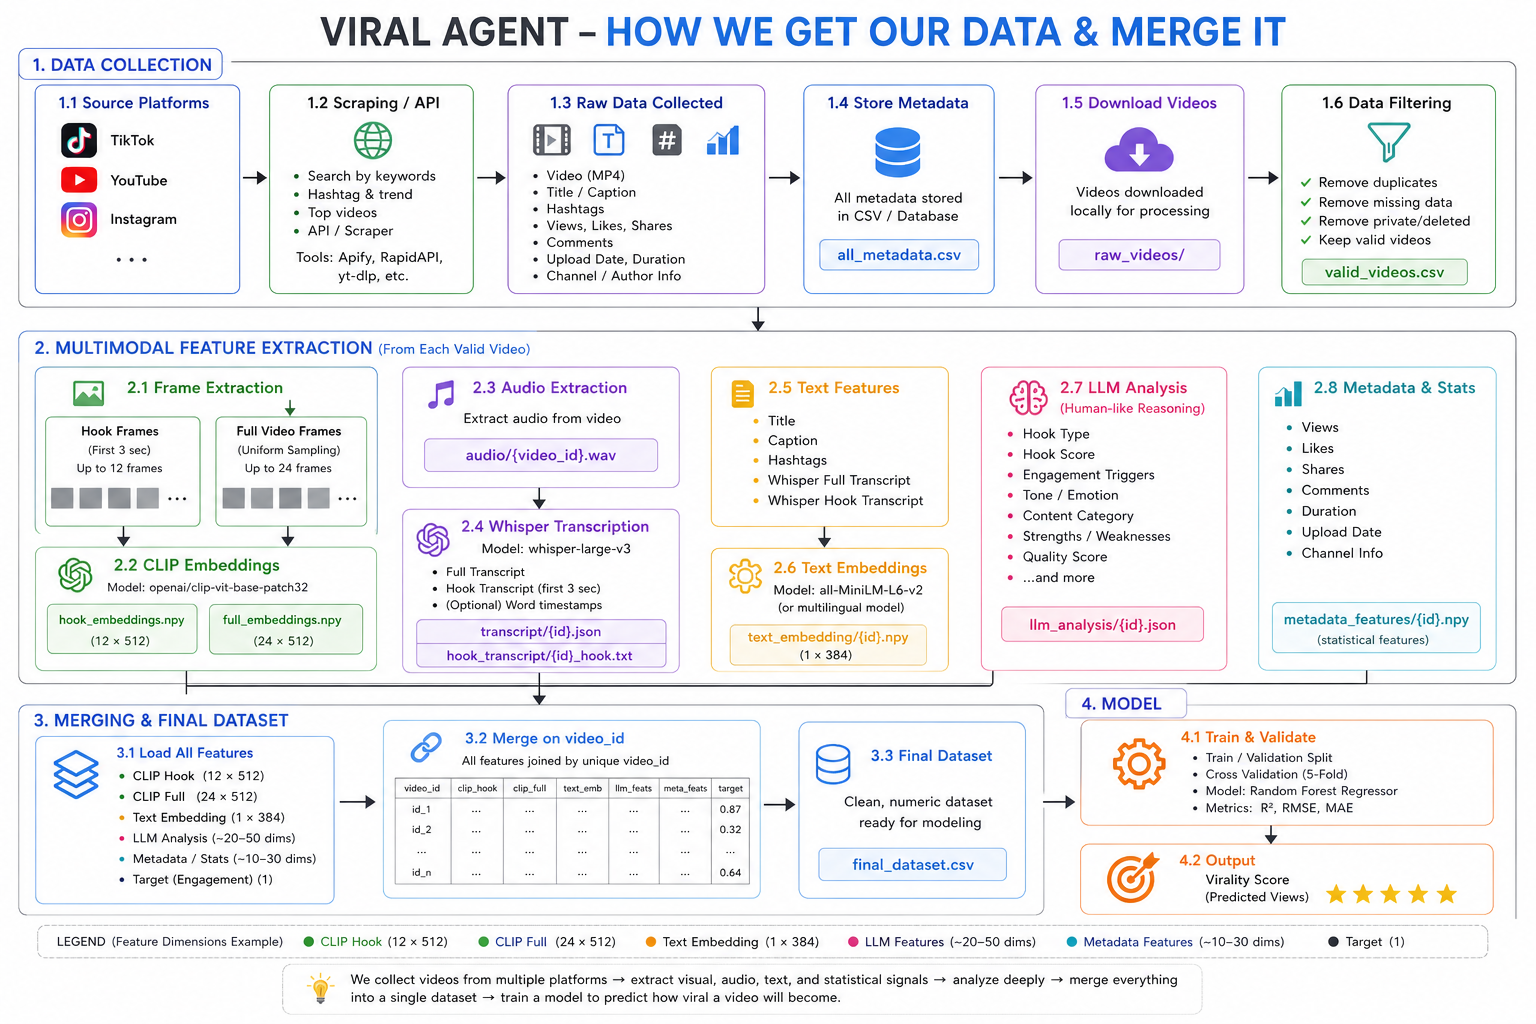

In [2]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [1]:
import numpy as np
import os
import pandas as pd
import numpy as np
import torch
from PIL import Image

In [3]:
import os
import pandas as pd

BASE = "/content/drive/MyDrive/viral_agent"
META_PATH = f"{BASE}/datasets/metadata/merged_metadata1.csv"

df = pd.read_csv(META_PATH)

df = df[df["local_video_path"].notna()]
df = df[df["local_video_path"].apply(os.path.exists)]
df = df.reset_index(drop=True)

print("Valid videos:", df.shape)
df[["video_id", "platform", "title", "local_video_path"]].head()

Valid videos: (1148, 24)


,video_id,platform,title,local_video_path
0,7629028827397639441,tiktok,فازات ماركيتينج - Marketing Tricks #marketing ...,/content/drive/MyDrive/viral_agent/datasets/ra...
1,7630978763202874646,tiktok,Khatina chabeb l photo dumps #fyp #tunisia🇹🇳 #...,/content/drive/MyDrive/viral_agent/datasets/ra...
2,7629440233678982407,tiktok,AI just spoke Tunisian Arabic fluently 😳 No ac...,/content/drive/MyDrive/viral_agent/datasets/ra...
3,7629160277929463071,tiktok,perfectly made 💛 #equestrian #horses,/content/drive/MyDrive/viral_agent/datasets/ra...
4,7614962372758850837,tiktok,I will never make a promise that I can’t keep#...,/content/drive/MyDrive/viral_agent/datasets/ra...


In [5]:
sample_path = df.loc[10, "local_video_path"]

print(sample_path)
print("Exists:", os.path.exists(sample_path))

/content/drive/MyDrive/viral_agent/datasets/raw_videos/tiktok/7626248345131945238.mp4
Exists: True


## whisper part

In [6]:
!pip install -q faster-whisper ffmpeg-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 77.9 MB/s eta 0:00:00


In [7]:
import os, json, subprocess
import pandas as pd
from tqdm import tqdm
from faster_whisper import WhisperModel

In [8]:
BASE = "/content/drive/MyDrive/viral_agent"
FEATURE_DIR = f"{BASE}/features"

AUDIO_DIR = f"{FEATURE_DIR}/audio"
TRANSCRIPT_DIR = f"{FEATURE_DIR}/transcripts"
HOOK_TRANSCRIPT_DIR = f"{FEATURE_DIR}/hook_transcripts"

os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(TRANSCRIPT_DIR, exist_ok=True)
os.makedirs(HOOK_TRANSCRIPT_DIR, exist_ok=True)

In [9]:
# Use large-v3 for quality
whisper_model = WhisperModel(
    "large-v3",
    device="cuda",
    compute_type="float16"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


RuntimeError: CUDA failed with error CUDA driver version is insufficient for CUDA runtime version

In [ ]:
def extract_audio(video_path, audio_path):
    if os.path.exists(audio_path):
        return audio_path

    cmd = [
        "ffmpeg", "-y",
        "-i", video_path,
        "-vn",
        "-acodec", "pcm_s16le",
        "-ar", "16000",
        "-ac", "1",
        audio_path
    ]

    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return audio_path if os.path.exists(audio_path) else None



In [ ]:
def transcribe_audio(audio_path):
    segments, info = whisper_model.transcribe(
        audio_path,
        beam_size=5,
        word_timestamps=True,
        vad_filter=True
    )

    segments_data = []
    full_text_parts = []
    hook_text_parts = []

    for seg in segments:
        text = seg.text.strip()

        segments_data.append({
            "start": seg.start,
            "end": seg.end,
            "text": text
        })

        full_text_parts.append(text)

        # hook transcript = speech happening in first 3 seconds
        if seg.start <= 3:
            hook_text_parts.append(text)

    full_transcript = " ".join(full_text_parts).strip()
    hook_transcript = " ".join(hook_text_parts).strip()

    return {
        "full_transcript": full_transcript,
        "hook_transcript": hook_transcript,
        "segments": segments_data,
        "language": info.language,
        "language_probability": info.language_probability
    }


In [ ]:

whisper_results = []
whisper_failed = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    video_id = str(row["video_id"])
    video_path = row["local_video_path"]

    audio_path = f"{AUDIO_DIR}/{video_id}.wav"
    transcript_path = f"{TRANSCRIPT_DIR}/{video_id}.json"
    hook_path = f"{HOOK_TRANSCRIPT_DIR}/{video_id}_hook.txt"

    # Skip if already done
    if os.path.exists(transcript_path) and os.path.exists(hook_path):
        whisper_results.append({
            "video_id": video_id,
            "transcript_path": transcript_path,
            "hook_transcript_path": hook_path
        })
        continue

    try:
        audio_path = extract_audio(video_path, audio_path)

        if audio_path is None:
            whisper_failed.append({
                "video_id": video_id,
                "reason": "audio extraction failed"
            })
            continue

        result = transcribe_audio(audio_path)

        with open(transcript_path, "w", encoding="utf-8") as f:
            json.dump(result, f, ensure_ascii=False, indent=2)

        with open(hook_path, "w", encoding="utf-8") as f:
            f.write(result["hook_transcript"])

        whisper_results.append({
            "video_id": video_id,
            "transcript_path": transcript_path,
            "hook_transcript_path": hook_path
        })

    except Exception as e:
        whisper_failed.append({
            "video_id": video_id,
            "reason": str(e)
        })

print("Whisper done:", len(whisper_results))
print("Whisper failed:", len(whisper_failed))

whisper_index = pd.DataFrame(whisper_results)
whisper_index.to_csv(f"{FEATURE_DIR}/whisper_transcript_index.csv", index=False)

failed_whisper_df = pd.DataFrame(whisper_failed)
failed_whisper_df.to_csv(f"{FEATURE_DIR}/failed_whisper.csv", index=False)

print("Saved:")
print(f"{FEATURE_DIR}/whisper_transcript_index.csv")
print(f"{FEATURE_DIR}/failed_whisper.csv")

  0%|          | 1/286 [00:32<2:32:38, 32.14s/it]


KeyboardInterrupt: 

### HOOK

In [ ]:
import cv2
import matplotlib.pyplot as plt

In [ ]:
def extract_hook_frames(video_path, hook_seconds=3, max_frames=12):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Could not open video:", video_path)
        return []

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_hook_frames = int(fps * hook_seconds)

    frame_indices = list(range(0, total_hook_frames, max(1, total_hook_frames // max_frames)))

    frames = []

    for idx in frame_indices[:max_frames]:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()

        if success:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

    cap.release()
    return frames

In [ ]:
sample_path = df.loc[0, "local_video_path"]

hook_frames = extract_hook_frames(sample_path)

print("Number of hook frames:", len(hook_frames))

In [ ]:
plt.figure(figsize=(15, 5))

for i, frame in enumerate(hook_frames):
    plt.subplot(1, len(hook_frames), i + 1)
    plt.imshow(frame)
    plt.axis("off")
    plt.title(f"Frame {i+1}")

plt.show()

# all vid frames

In [ ]:
def extract_full_video_frames(video_path, max_frames=24):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Could not open video:", video_path)
        return []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return []

    frame_indices = np.linspace(0, total_frames - 1, max_frames).astype(int)

    frames = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()

        if success:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

    cap.release()
    return frames

In [ ]:
full_frames = extract_full_video_frames(sample_path)

print("Number of full-video frames:", len(full_frames))

In [ ]:
plt.figure(figsize=(18, 6))

for i, frame in enumerate(full_frames):
    plt.subplot(3, 8, i + 1)
    plt.imshow(frame)
    plt.axis("off")
    plt.title(f"{i+1}")

plt.show()

### CLIP embeddings

In [ ]:
!pip install -q transformers torch torchvision pillow

In [ ]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import numpy as np

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

clip_model.eval()

In [ ]:
def encode_frames_clip(frames):
    images = [Image.fromarray(frame) for frame in frames]

    inputs = clip_processor(
        images=images,
        return_tensors="pt",
        padding=True
    ).to(DEVICE)

    with torch.no_grad():
        outputs = clip_model.vision_model(
            pixel_values=inputs["pixel_values"]
        )

        # get pooled visual output
        features = outputs.pooler_output

        # apply CLIP visual projection
        features = clip_model.visual_projection(features)

    # normalize each frame embedding
    features = features / features.norm(dim=-1, keepdim=True)

    # mean pooling into one video embedding
    embedding = features.mean(dim=0)
    embedding = embedding / embedding.norm()

    return embedding.cpu().numpy()

In [ ]:
hook_embedding = encode_frames_clip(hook_frames)
full_video_embedding = encode_frames_clip(full_frames)

print("Hook:", hook_embedding.shape)
print("Full:", full_video_embedding.shape)

# save embeddings for this one test video

In [ ]:
import os
import numpy as np

BASE = "/content/drive/MyDrive/viral_agent"
FEATURE_DIR = f"{BASE}/features"
os.makedirs(FEATURE_DIR, exist_ok=True)

In [ ]:
test_video_id = df.loc[0, "video_id"]

np.save(f"{FEATURE_DIR}/{test_video_id}_hook_embedding.npy", hook_embedding)
np.save(f"{FEATURE_DIR}/{test_video_id}_full_video_embedding.npy", full_video_embedding)

print("Saved embeddings for:", test_video_id)
print("Hook shape:", hook_embedding.shape)
print("Full shape:", full_video_embedding.shape)

In [ ]:
loaded_hook = np.load(f"{FEATURE_DIR}/{test_video_id}_hook_embedding.npy")
loaded_full = np.load(f"{FEATURE_DIR}/{test_video_id}_full_video_embedding.npy")

print("Loaded hook:", loaded_hook.shape)
print("Loaded full:", loaded_full.shape)

In [ ]:
import os
import numpy as np
from tqdm import tqdm

FEATURE_DIR = "/content/drive/MyDrive/viral_agent/features"
os.makedirs(FEATURE_DIR, exist_ok=True)

HOOK_EMB_DIR = f"{FEATURE_DIR}/hook_embeddings"
FULL_EMB_DIR = f"{FEATURE_DIR}/full_video_embeddings"

os.makedirs(HOOK_EMB_DIR, exist_ok=True)
os.makedirs(FULL_EMB_DIR, exist_ok=True)

In [ ]:
failed = []
processed = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    video_id = str(row["video_id"])
    video_path = row["local_video_path"]

    hook_save_path = f"{HOOK_EMB_DIR}/{video_id}_hook.npy"
    full_save_path = f"{FULL_EMB_DIR}/{video_id}_full.npy"

    # Skip if already processed
    if os.path.exists(hook_save_path) and os.path.exists(full_save_path):
        processed.append(video_id)
        continue

    try:
        hook_frames = extract_hook_frames(
            video_path,
            hook_seconds=3,
            max_frames=12
        )

        full_frames = extract_full_video_frames(
            video_path,
            max_frames=24
        )

        if len(hook_frames) == 0 or len(full_frames) == 0:
            failed.append({
                "video_id": video_id,
                "reason": "no frames extracted"
            })
            continue

        hook_embedding = encode_frames_clip(hook_frames)
        full_embedding = encode_frames_clip(full_frames)

        np.save(hook_save_path, hook_embedding)
        np.save(full_save_path, full_embedding)

        processed.append(video_id)

    except Exception as e:
        failed.append({
            "video_id": video_id,
            "reason": str(e)
        })

print("Processed:", len(processed))
print("Failed:", len(failed))

In [ ]:
import pandas as pd

failed_df = pd.DataFrame(failed)
failed_path = f"{FEATURE_DIR}/failed_clip_embeddings.csv"
failed_df.to_csv(failed_path, index=False)

print("Failure log saved to:", failed_path)
failed_df.head()

In [ ]:
# 2) Save processed video IDs
processed_df = pd.DataFrame({"video_id": processed})
processed_df.to_csv(f"{FEATURE_DIR}/processed_clip_embeddings.csv", index=False)

# 3) Save embedding index
records = []

for video_id in processed:
    records.append({
        "video_id": video_id,
        "hook_path": f"{HOOK_EMB_DIR}/{video_id}_hook.npy",
        "full_path": f"{FULL_EMB_DIR}/{video_id}_full.npy"
    })

embedding_index = pd.DataFrame(records)
embedding_index.to_csv(f"{FEATURE_DIR}/embedding_index.csv", index=False)

print("Saved:")
print(f"{FEATURE_DIR}/failed_clip_embeddings.csv")
print(f"{FEATURE_DIR}/processed_clip_embeddings.csv")
print(f"{FEATURE_DIR}/embedding_index.csv")
print("Processed:", len(processed))
print("Failed:", len(failed))

In [ ]:
import os

print("Hook files:", len(os.listdir(HOOK_EMB_DIR)))
print("Full files:", len(os.listdir(FULL_EMB_DIR)))

in case rerun from here



In [ ]:
BASE = "/content/drive/MyDrive/viral_agent"
FEATURE_DIR = f"{BASE}/features"

HOOK_EMB_DIR = f"{FEATURE_DIR}/hook_embeddings"
FULL_EMB_DIR = f"{FEATURE_DIR}/full_video_embeddings"

In [ ]:
df = pd.read_csv(f"{BASE}/datasets/metadata/all_metadata.csv")

In [ ]:
embedding_index = pd.read_csv(f"{FEATURE_DIR}/embedding_index.csv")
print(embedding_index.shape)
embedding_index.head()

In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
# TEXT EMBEDDINGS — title + Whisper transcript + hook transcript
!pip install -q sentence-transformers

import os, json
import numpy as np
import pandas as pd
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

TEXT_EMB_DIR = f"{FEATURE_DIR}/text_embeddings"
os.makedirs(TEXT_EMB_DIR, exist_ok=True)

text_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")


In [ ]:
whisper_index = pd.read_csv(f"{FEATURE_DIR}/whisper_transcript_index.csv")
whisper_index["video_id"] = whisper_index["video_id"].astype(str)
df["video_id"] = df["video_id"].astype(str)

df_text = df.merge(whisper_index, on="video_id", how="inner")

text_processed = []
text_failed = []

for idx, row in tqdm(df_text.iterrows(), total=len(df_text)):
    video_id = str(row["video_id"])
    save_path = f"{TEXT_EMB_DIR}/{video_id}_text.npy"

    if os.path.exists(save_path):
        text_processed.append(video_id)
        continue

    try:
        title = str(row.get("title", ""))

        with open(row["transcript_path"], "r", encoding="utf-8") as f:
            transcript_data = json.load(f)

        full_transcript = transcript_data.get("full_transcript", "")
        hook_transcript = transcript_data.get("hook_transcript", "")

        combined_text = f"""
        Title: {title}

        Hook Transcript:
        {hook_transcript}

        Full Transcript:
        {full_transcript}
        """

        embedding = text_model.encode(combined_text)
        np.save(save_path, embedding)

        text_processed.append(video_id)

    except Exception as e:
        text_failed.append({
            "video_id": video_id,
            "reason": str(e)
        })

print("Text processed:", len(text_processed))
print("Text failed:", len(text_failed))

text_index = pd.DataFrame({
    "video_id": text_processed,
    "text_path": [f"{TEXT_EMB_DIR}/{vid}_text.npy" for vid in text_processed]
})

text_index.to_csv(f"{FEATURE_DIR}/text_embedding_index.csv", index=False)
pd.DataFrame(text_failed).to_csv(f"{FEATURE_DIR}/failed_text_embeddings.csv", index=False)

print("Saved text index")

In [ ]:
text = df.loc[0, "title"]

embedding = model.encode(text)

print("Text:", text)
print("Shape:", embedding.shape)

In [ ]:
TEXT_EMB_DIR = f"{FEATURE_DIR}/text_embeddings"
os.makedirs(TEXT_EMB_DIR, exist_ok=True)

In [ ]:
from tqdm import tqdm

text_processed = []
text_failed = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    video_id = str(row["video_id"])
    text = str(row["title"])

    save_path = f"{TEXT_EMB_DIR}/{video_id}_text.npy"

    # skip if already exists
    if os.path.exists(save_path):
        text_processed.append(video_id)
        continue

    try:
        embedding = model.encode(text)
        np.save(save_path, embedding)
        text_processed.append(video_id)

    except Exception as e:
        text_failed.append({
            "video_id": video_id,
            "reason": str(e)
        })

print("Text processed:", len(text_processed))
print("Text failed:", len(text_failed))

In [ ]:
records = []

for video_id in text_processed:
    records.append({
        "video_id": video_id,
        "text_path": f"{TEXT_EMB_DIR}/{video_id}_text.npy"
    })

text_index = pd.DataFrame(records)
text_index.to_csv(f"{FEATURE_DIR}/text_embedding_index.csv", index=False)

print("Saved text index")

🚀 Next step (VERY IMPORTANT)

After this, we will:

👉 MERGE EVERYTHING

We will combine:

metadata
+ hook embeddings
+ full video embeddings
+ text embeddings
+ target log_views

metadata + hook + full + text → FINAL DATASET

👉 Then train the real model

In [ ]:
import pandas as pd
import numpy as np
import os

BASE = "/content/drive/MyDrive/viral_agent"
FEATURE_DIR = f"{BASE}/features"

df = pd.read_csv(f"{BASE}/datasets/metadata/all_metadata.csv")
embedding_index = pd.read_csv(f"{FEATURE_DIR}/embedding_index.csv")
text_index = pd.read_csv(f"{FEATURE_DIR}/text_embedding_index.csv")

df["video_id"] = df["video_id"].astype(str)
embedding_index["video_id"] = embedding_index["video_id"].astype(str)
text_index["video_id"] = text_index["video_id"].astype(str)

In [ ]:
merged = df.merge(embedding_index, on="video_id", how="inner")
merged = merged.merge(text_index, on="video_id", how="inner")

print("Merged shape:", merged.shape)
merged.head()

In [ ]:
from tqdm import tqdm

hook_vectors = []
full_vectors = []
text_vectors = []
valid_rows = []


for i, row in tqdm(merged.iterrows(), total=len(merged)):
    try:
        hook = np.load(row["hook_path"])
        full = np.load(row["full_path"])
        text = np.load(row["text_path"])

        hook_vectors.append(hook)
        full_vectors.append(full)
        text_vectors.append(text)
        valid_rows.append(i)

    except Exception as e:
        print("Skipping:", row["video_id"], e)

merged = merged.loc[valid_rows].reset_index(drop=True)

hook_vectors = np.vstack(hook_vectors)
full_vectors = np.vstack(full_vectors)
text_vectors = np.vstack(text_vectors)

print("Hook:", hook_vectors.shape)
print("Full:", full_vectors.shape)
print("Text:", text_vectors.shape)
print("Metadata:", merged.shape)

In [ ]:
hook_df = pd.DataFrame(hook_vectors, columns=[f"hook_{i}" for i in range(hook_vectors.shape[1])])
full_df = pd.DataFrame(full_vectors, columns=[f"full_{i}" for i in range(full_vectors.shape[1])])
text_df = pd.DataFrame(text_vectors, columns=[f"text_{i}" for i in range(text_vectors.shape[1])])

In [ ]:
merged["log_views"] = np.log1p(merged["views"])

In [ ]:
metadata_cols = [
    "video_id",
    "platform",
    "views",
    "likes",
    "comments",
    "duration_seconds",
    "log_views"
]

In [ ]:
final_df = pd.concat(
    [
        merged[metadata_cols].reset_index(drop=True),
        hook_df,
        full_df,
        text_df
    ],
    axis=1
)

print("Final dataset shape:", final_df.shape)

In [ ]:
save_path = f"{FEATURE_DIR}/final_model_dataset.csv"
final_df.to_csv(save_path, index=False)

print("Saved to:", save_path)

In [ ]:
X = final_df.drop(columns=[
    "video_id",
    "platform",
    "views",
    "log_views"
])

y = final_df["log_views"]

print("X shape:", X.shape)
print("y shape:", y.shape)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_

feat_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

feat_importance = feat_importance.sort_values(by="importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.barh(feat_importance["feature"], feat_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importance")
plt.show()

In [ ]:
# Add hook/full cosine similarity
# Remove leakage
# Run cross-validation
# Compare feature groups

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
BASE        = "/content/drive/MyDrive/viral_agent"
FEATURE_DIR = f"{BASE}/features"
HOOK_EMB_DIR  = f"{FEATURE_DIR}/hook_embeddings"
FULL_EMB_DIR  = f"{FEATURE_DIR}/full_video_embeddings"
TEXT_EMB_DIR  = f"{FEATURE_DIR}/text_embeddings"
LLM_DIR       = f"{FEATURE_DIR}/llm_features"

os.makedirs(LLM_DIR, exist_ok=True)

df = pd.read_csv(f"{BASE}/datasets/metadata/all_metadata.csv")
df["video_id"] = df["video_id"].astype(str)
print("Metadata shape:", df.shape)

embedding_index = pd.read_csv(f"{FEATURE_DIR}/embedding_index.csv")
text_index      = pd.read_csv(f"{FEATURE_DIR}/text_embedding_index.csv")
embedding_index["video_id"] = embedding_index["video_id"].astype(str)
text_index["video_id"]      = text_index["video_id"].astype(str)

merged = df.merge(embedding_index, on="video_id", how="inner")
merged = merged.merge(text_index,  on="video_id", how="inner")
merged = merged.reset_index(drop=True)
print("Merged shape:", merged.shape)

# ── Load embedding vectors ───────────────────────────────────
from tqdm import tqdm

hook_vectors  = []
full_vectors  = []
text_vectors  = []
valid_rows    = []

for i, row in tqdm(merged.iterrows(), total=len(merged), desc="Loading embeddings"):
    try:
        hook = np.load(row["hook_path"])
        full = np.load(row["full_path"])
        text = np.load(row["text_path"])
        hook_vectors.append(hook)
        full_vectors.append(full)
        text_vectors.append(text)
        valid_rows.append(i)
    except Exception as e:
        print(f"Skipping video_id={row['video_id']} — {e}")

merged       = merged.loc[valid_rows].reset_index(drop=True)
hook_vectors = np.vstack(hook_vectors)   # (286, 512)
full_vectors = np.vstack(full_vectors)   # (286, 512)
text_vectors = np.vstack(text_vectors)   # (286, 384)

print("\n✅ All loaded:")
print(f"   hook_vectors : {hook_vectors.shape}")
print(f"   full_vectors : {full_vectors.shape}")
print(f"   text_vectors : {text_vectors.shape}")
print(f"   merged       : {merged.shape}")

# ── Rebuild final_df (same as end of your original notebook) ─
hook_df = pd.DataFrame(hook_vectors, columns=[f"hook_{i}" for i in range(hook_vectors.shape[1])])
full_df = pd.DataFrame(full_vectors, columns=[f"full_{i}" for i in range(full_vectors.shape[1])])
text_df = pd.DataFrame(text_vectors, columns=[f"text_{i}" for i in range(text_vectors.shape[1])])

merged["log_views"] = np.log1p(merged["views"])

metadata_cols = ["video_id", "platform", "views", "likes", "comments", "duration_seconds", "log_views"]

final_df = pd.concat(
    [merged[metadata_cols].reset_index(drop=True), hook_df, full_df, text_df],
    axis=1
)

print("\nfinal_df shape:", final_df.shape)
print("Ready ✅ — now run Cell 2 onwards")

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Cosine similarity between hook and full video for each video
hook_full_sim = np.array([
    cosine_similarity(hook_vectors[i].reshape(1, -1), full_vectors[i].reshape(1, -1))[0][0]
    for i in range(len(hook_vectors))
])

print("Hook-Full similarity stats:")
print(f"  Mean: {hook_full_sim.mean():.3f}")
print(f"  Std:  {hook_full_sim.std():.3f}")
print(f"  Min:  {hook_full_sim.min():.3f}")
print(f"  Max:  {hook_full_sim.max():.3f}")

In [ ]:
!pip install -q groq

In [ ]:
import os
from getpass import getpass

os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")

In [ ]:
import json
from groq import Groq

client = Groq(api_key=os.environ["GROQ_API_KEY"])

def analyze_video_with_groq(title, platform, duration_seconds=None):
    prompt = f"""
You are analyzing a short-form viral video.

Video info:
- Platform: {platform}
- Title / caption: {title}
- Duration seconds: {duration_seconds}

Return ONLY valid JSON with this structure:

{{
  "hook_type": "curiosity / shock / tutorial / emotional / transformation / comedy / other",
  "hook_score": 0,
  "clarity_score": 0,
  "emotion": "string",
  "tone": "string",
  "content_category": "string",
  "engagement_triggers": ["trigger1", "trigger2"],
  "strengths": ["strength1", "strength2"],
  "weaknesses": ["weakness1", "weakness2"],
  "quality_score": 0,
  "improvement_suggestion": "string"
}}

Scores must be from 0 to 10.
"""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "system",
                "content": "You are a strict JSON generator and expert viral video analyst."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0.1,
        max_tokens=800,
        response_format={"type": "json_object"}
    )

    return json.loads(response.choices[0].message.content)


In [ ]:
row = final_df.iloc[0]

analysis = analyze_video_with_groq(
    title=row.get("caption_or_title", ""),
    platform=row.get("platform", ""),
    duration_seconds=row.get("duration_seconds", None)
)

analysis

In [ ]:
import time

llm_results = []
failed_llm = []

for idx, row in tqdm(merged.iterrows(), total=len(merged)):
    video_id = str(row["video_id"])
    save_path = f"{LLM_DIR}/{video_id}_llm.json"

    # skip if already done
    if os.path.exists(save_path):
        try:
            with open(save_path, "r") as f:
                saved = json.load(f)
            llm_results.append({"video_id": video_id, **saved})
            continue
        except:
            pass

    try:
        title = str(row["caption_or_title"]) if "caption_or_title" in row else str(row.get("title", ""))

        result = analyze_video_with_groq(
            title=title,
            platform=str(row["platform"]),
            duration_seconds=row.get("duration_seconds", None)
        )

        result["video_id"] = video_id

        with open(save_path, "w") as f:
            json.dump(result, f, indent=2)

        llm_results.append(result)

    except Exception as e:
        failed_llm.append({
            "video_id": video_id,
            "reason": str(e)
        })

    time.sleep(0.5)

print("LLM analyzed:", len(llm_results))
print("LLM failed:", len(failed_llm))

In [ ]:
llm_df = pd.DataFrame(llm_results)
llm_df["video_id"] = llm_df["video_id"].astype(str)

# --- CATEGORICAL FEATURES ---
categorical_cols = [
    "hook_type",
    "tone",
    "emotion",
    "content_category"
]

llm_encoded = pd.get_dummies(
    llm_df[
        categorical_cols + [
            "video_id",
            "hook_score",
            "clarity_score",
            "quality_score"
        ]
    ],
    columns=categorical_cols
)

# --- LIST FEATURES (counts) ---
llm_encoded["num_strengths"] = llm_df["strengths"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

llm_encoded["num_weaknesses"] = llm_df["weaknesses"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

llm_encoded["num_engagement_triggers"] = llm_df["engagement_triggers"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

print("LLM feature shape:", llm_encoded.shape)
llm_encoded.head()

In [ ]:
# Merge LLM features
final_df2 = final_df.merge(llm_encoded, on="video_id", how="inner")

# DROP leakage columns
leaky_cols = [
    "likes",
    "comments",
    "views",
    "log_views",
    "video_id",
    "platform"
]

X2 = final_df2.drop(columns=leaky_cols)
y2 = final_df2["log_views"]

print("New X shape:", X2.shape)
print("y shape:", y2.shape)

 Train with cross-validation (no more blind train/test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,       # reduced to fight overfitting on small dataset
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

cv_r2   = cross_val_score(rf, X2, y2, cv=kf, scoring="r2")
cv_rmse = cross_val_score(rf, X2, y2, cv=kf,
                           scoring="neg_root_mean_squared_error")

print("=== 5-Fold Cross Validation Results ===")
print(f"R²   — mean: {cv_r2.mean():.3f}  std: {cv_r2.std():.3f}")
print(f"RMSE — mean: {-cv_rmse.mean():.3f}  std: {cv_rmse.std():.3f}")

# Final fit on all data to inspect feature importance
rf.fit(X2, y2)

In [ ]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feature_names = X2.columns

top_n = 20
indices = np.argsort(importances)[-top_n:]

plt.figure(figsize=(10, 7))
plt.barh(range(top_n), importances[indices])
plt.yticks(range(top_n), [feature_names[i] for i in indices])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

# Print LLM-specific feature importances
llm_feature_names = [c for c in feature_names if any(
    c.startswith(p) for p in ["hook_", "clarity", "quality", "pacing",
                               "tone_", "emotion_", "structure_", "num_"]
)]
llm_importances = {f: importances[list(feature_names).index(f)]
                   for f in llm_feature_names if f in list(feature_names)}
llm_sorted = sorted(llm_importances.items(), key=lambda x: x[1], reverse=True)

print("\n=== LLM Feature Importances ===")
for name, score in llm_sorted[:15]:
    print(f"  {name}: {score:.4f}")